<a href="https://colab.research.google.com/github/subhra015/Internship/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
# Alternative: Used seaborn's built-in dataset
df = sns.load_dataset('titanic')

# Renamed columns to match your sample code (capitalized)
df = df.rename(columns={
    'survived': 'Survived',
    'pclass': 'Pclass',
    'sex': 'Sex',
    'age': 'Age',
    'sibsp': 'SibSp',
    'parch': 'Parch',
    'fare': 'Fare',
    'embarked': 'Embarked',
    'class': 'Class',
    'who': 'Who',
    'adult_male': 'AdultMale',
    'deck': 'Deck',
    'embark_town': 'EmbarkTown',
    'alive': 'Alive',
    'alone': 'Alone'
})

In [25]:
# Preview data
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked  Class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     Who  AdultMale Deck   EmbarkTown Alive  Alone  
0    man       True  NaN  Southampton    no  False  
1  woman      False    C    Cherbourg   yes  False  
2  woman      False  NaN  Southampton   yes   True  
3  woman      False    C  Southampton   yes  False  
4    man       True  NaN  Southampton    no   True  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Survived    891 

In [26]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
print("Missing Age values filled with mean:", df["Age"].mean())

Missing Age values filled with mean: 29.69911764705882


In [27]:
# Drop irrelevant columns
# After renaming, the column is 'Deck' (capital D), not 'deck'
df = df.drop(columns=["Deck"])

print("Dropped 'Deck' column")
print("Remaining columns:", list(df.columns))

Dropped 'Deck' column
Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Class', 'Who', 'AdultMale', 'EmbarkTown', 'Alive', 'Alone']


In [28]:
# Create Age Groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

print("AgeGroup column created!")
print(df["AgeGroup"].value_counts())

AgeGroup column created!
AgeGroup
YoungAdult    447
Adult         241
Teen           70
Child          69
Senior         64
Name: count, dtype: int64


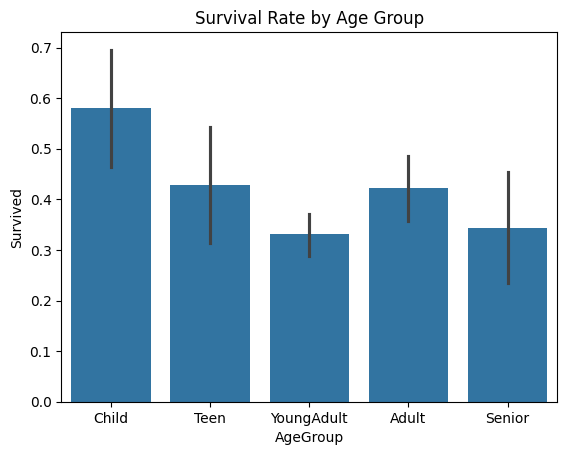

Survival rate by Age Group:
AgeGroup
Child         0.579710
Teen          0.428571
Adult         0.423237
Senior        0.343750
YoungAdult    0.331096
Name: Survived, dtype: float64


/tmp/ipykernel_3008/3393271274.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("AgeGroup")["Survived"].mean().sort_values(ascending=False))


In [29]:
# Survival by Age Group
sns.barplot(x="AgeGroup", y="Survived", data=df)
plt.title("Survival Rate by Age Group")
plt.show()

print("Survival rate by Age Group:")
print(df.groupby("AgeGroup")["Survived"].mean().sort_values(ascending=False))

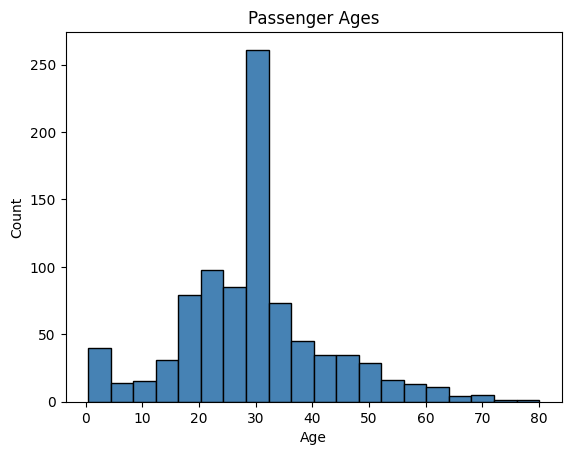

Mean Age: 29.7
Median Age: 29.7


In [30]:
# Age distribution histogram
df["Age"].plot(kind="hist", bins=20, title="Passenger Ages", color="steelblue", edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

print(f"Mean Age: {df['Age'].mean():.1f}")
print(f"Median Age: {df['Age'].median():.1f}")

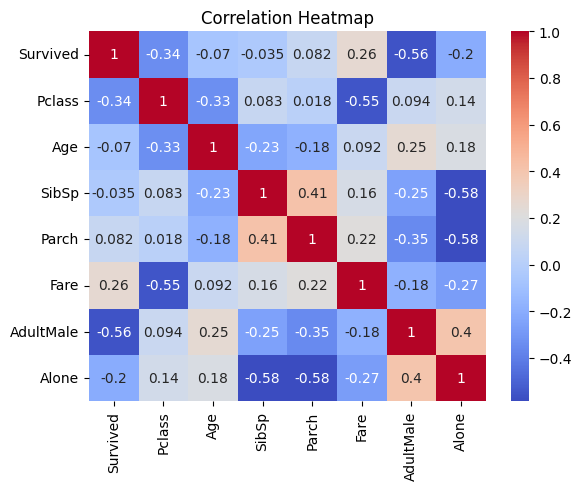

In [31]:
# Heatmap of correlations
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [32]:
# Create Family Size feature
df["FamilySize"] = df["SibSp"] + df["Parch"]

print("FamilySize column created!")
print(df["FamilySize"].value_counts().sort_index())

FamilySize column created!
FamilySize
0     537
1     161
2     102
3      29
4      15
5      22
6      12
7       6
10      7
Name: count, dtype: int64


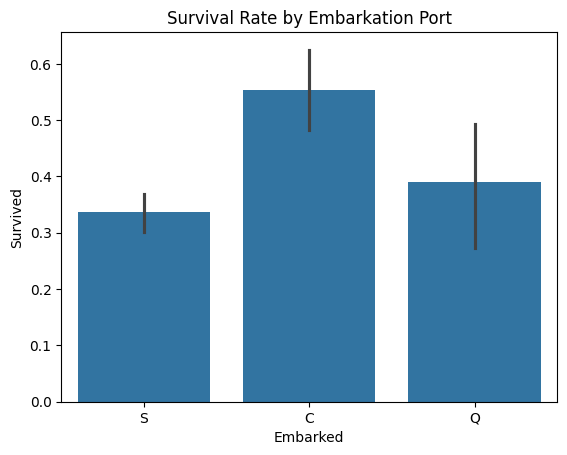

Survival rate by Embarkation Port:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [33]:
# Survival rate by Embarkation Port
sns.barplot(x="Embarked", y="Survived", data=df)
plt.title("Survival Rate by Embarkation Port")
plt.show()

print("Survival rate by Embarkation Port:")
print(df.groupby("Embarked")["Survived"].mean().sort_values(ascending=False))

In [34]:
print("=" * 60)
print("TITANIC EDA - TASK 3 COMPLETE")
print("=" * 60)

print(f"""
 DATASET OVERVIEW:
   • Total Passengers: {df.shape[0]}
   • Features Analyzed: Age, Class, Gender, Family Size, Embarked

 KEY FINDINGS:

1️ SURVIVAL BY AGE GROUP:
   • {df.groupby('AgeGroup')['Survived'].mean().sort_values(ascending=False).index[0]}: {df.groupby('AgeGroup')['Survived'].mean().max():.2%} survival rate
   → Children had better survival chances!

2️ SURVIVAL BY FAMILY SIZE:
   • Best survival at family size {df.groupby('FamilySize')['Survived'].mean().idxmax()}
   • Solo travelers had lower survival rates

3️ SURVIVAL BY EMBARKATION PORT:
   • {df.groupby('Embarked')['Survived'].mean().sort_values(ascending=False).index[0]} had highest survival rate
   • Port may correlate with passenger class

4️ CORRELATIONS (from Heatmap):
   • Fare positively correlated with survival
   • Pclass negatively correlated with survival

 CONCLUSION:
   "Women and Children First" + Higher Class + Smaller Families
   = Better survival chances on the Titanic.
""")

print("=" * 60)
print(" TASK 2 COMPLETED SUCCESSFULLY!")
print("=" * 60)

TITANIC EDA - TASK 3 COMPLETE

 DATASET OVERVIEW:
   • Total Passengers: 891
   • Features Analyzed: Age, Class, Gender, Family Size, Embarked

 KEY FINDINGS:

1️ SURVIVAL BY AGE GROUP:
   • Child: 57.97% survival rate
   → Children had better survival chances!

2️ SURVIVAL BY FAMILY SIZE:
   • Best survival at family size 3
   • Solo travelers had lower survival rates

3️ SURVIVAL BY EMBARKATION PORT:
   • C had highest survival rate
   • Port may correlate with passenger class

4️ CORRELATIONS (from Heatmap):
   • Fare positively correlated with survival
   • Pclass negatively correlated with survival

 CONCLUSION:
   "Women and Children First" + Higher Class + Smaller Families 
   = Better survival chances on the Titanic.

 TASK 2 COMPLETED SUCCESSFULLY!


/tmp/ipykernel_3008/3340622558.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  • {df.groupby('AgeGroup')['Survived'].mean().sort_values(ascending=False).index[0]}: {df.groupby('AgeGroup')['Survived'].mean().max():.2%} survival rate
